# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [48]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

%matplotlib inline

In [164]:
%load_ext autoreload
%autoreload 2

# Add the source path to Python path
src_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method import MicroTOFMethod
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.diann.anndiannloader import DiannLoader
from parsers.diann.diann_collection import DiannCollection
from parsers.diann.diann_plotting import *


# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Base

In [50]:
source = 'base'

In [51]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

#### LC Collection Object

In [52]:
lccollection = VNeoMethodCollection()

In [53]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/data/methods/LC/Trap')

## MS Methods

### Load MS Methods

In [54]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [55]:
mscollection.add_methods_from_folder(f"{base}MethodOpt/LCMSmethodAnalysis/data/methods/MS/msmethods_260311.zip")
msmethod_names = '\n'.join(mscollection.methods.keys())

### BPS

In [12]:
# bpscollection = DiannCollection(log_file = f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/log/trapbpscollection.log')

In [10]:
# bpscollection.add_searches(f'{base}MethodOpt/LCMSmethodAnalysis/data/BPS/hela_bps_trap_260311_11am.zip',
#                             search_type='bps',
#                             levels=['precursor'])

In [30]:
# bpscollection.save(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl


In [31]:
bpscollection = DiannCollection.from_file(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl


In [ ]:
# map_lcms_methods(bpscollection, f'{base}MethodOpt/LCMSmethodAnalysis/data/sequences/2026_03.csv')

In [11]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


## Adjusted LC Meth

In [56]:
lccollection.bulk_adjust_gradients(bpscollection)

In [138]:
# lccollection.adjusted_methods['ML25p5FR200V9A15TrapNS5']['HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_FR200V9A15TrapNS5_DIA50ms122_TT0000475_R-H1_1_14985'].gradient

In [57]:
sample_subset = bpscollection['precursor'].var
sample_subset = sample_subset[sample_subset['hystar_index'].isin(['14987',
                                                                  '14970',
                                                                  '14971',
                                                                  '14969'])]

(<Axes: title={'center': 'Gradient Comparison'}, xlabel='time [min]', ylabel='Value'>,
 <Axes: ylabel='Neo.PumpModule.Pump.%B.Value [%]'>,
 <Axes: ylabel='Neo.PumpModule.Pump.Curve'>)

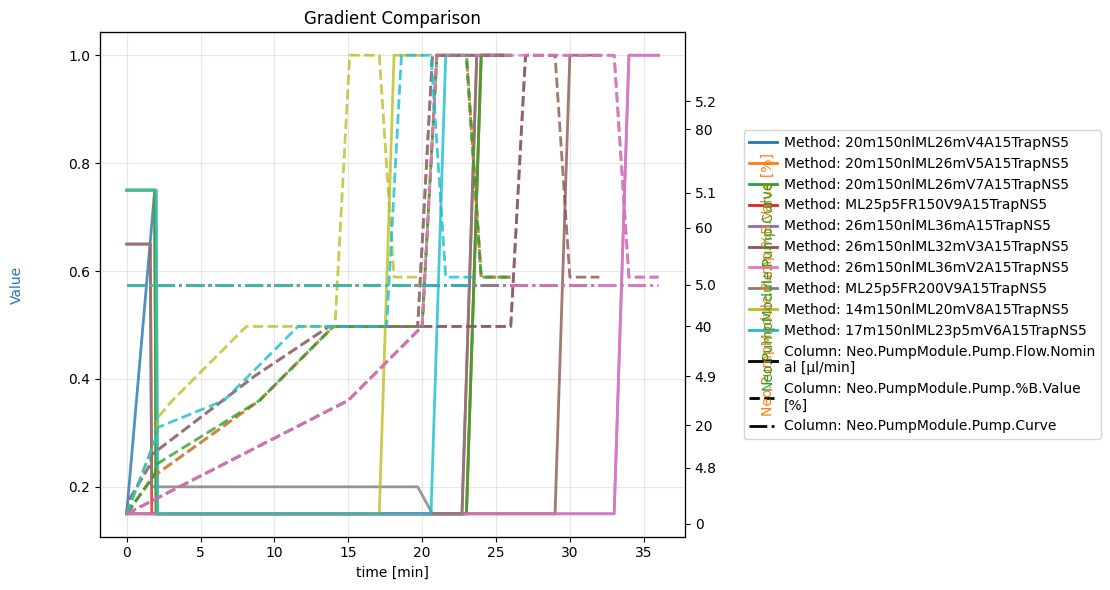

In [58]:
lccollection.plot_gradients(y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
                                        'Neo.PumpModule.Pump.%B.Value [%]','Neo.PumpModule.Pump.Curve'],
                                        twin_axes=True) 

In [59]:
test = bpscollection['precursor'][:, sample_subset['File.Name']]

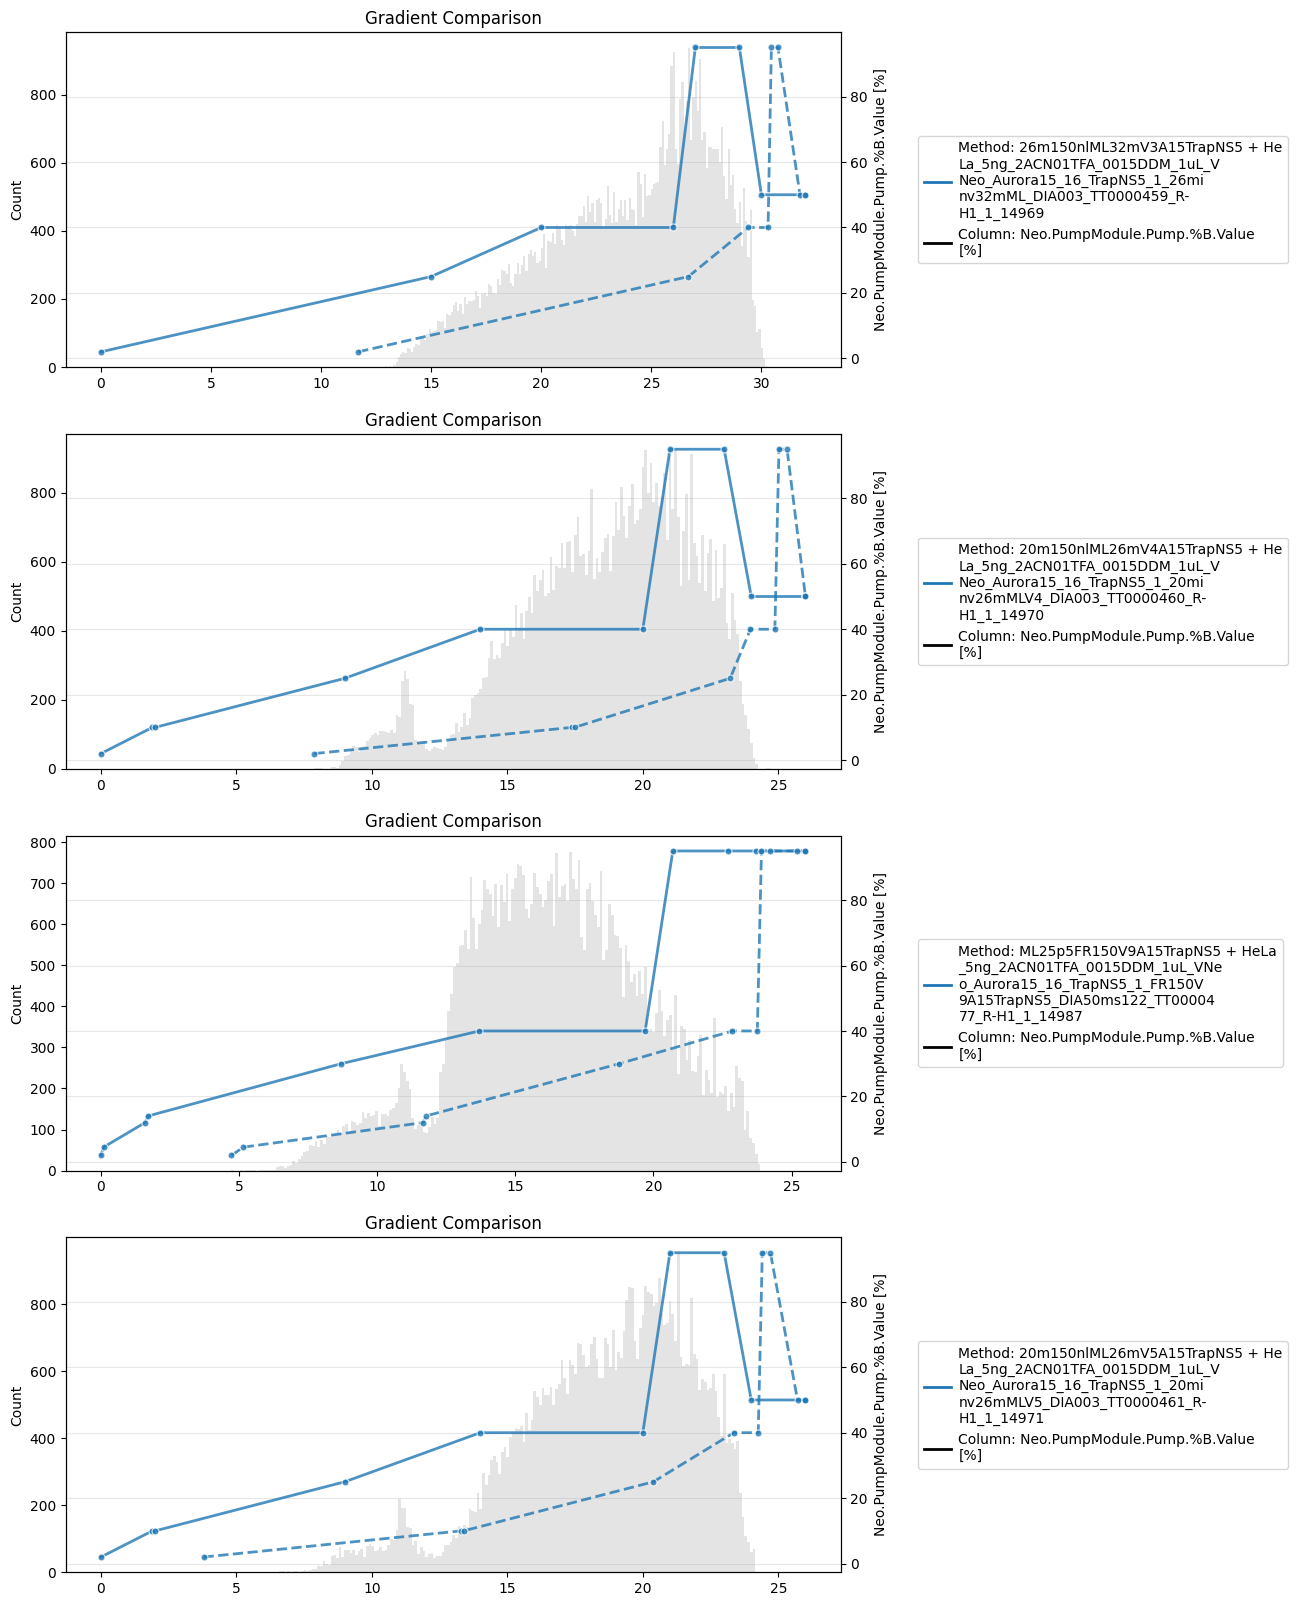

In [89]:
fig, ax = plt.subplots(figsize=(10, 20), nrows=4)

for i, name in enumerate(test.var_names):
    temp_ax = ax[i].twinx()
    sns.histplot(x = test[:, name].layers['RT'].flatten(), ax=ax[i], edgecolor=None, color='lightgrey', alpha=0.6, binwidth=0.1)
    lccollection.plot_gradients(sample_var = sample_subset.loc[[name]],
                                x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                                y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'],
                                ax=temp_ax, 
                                markers=True)

<Axes: title={'center': 'Gradient Comparison'}, xlabel='X Value', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

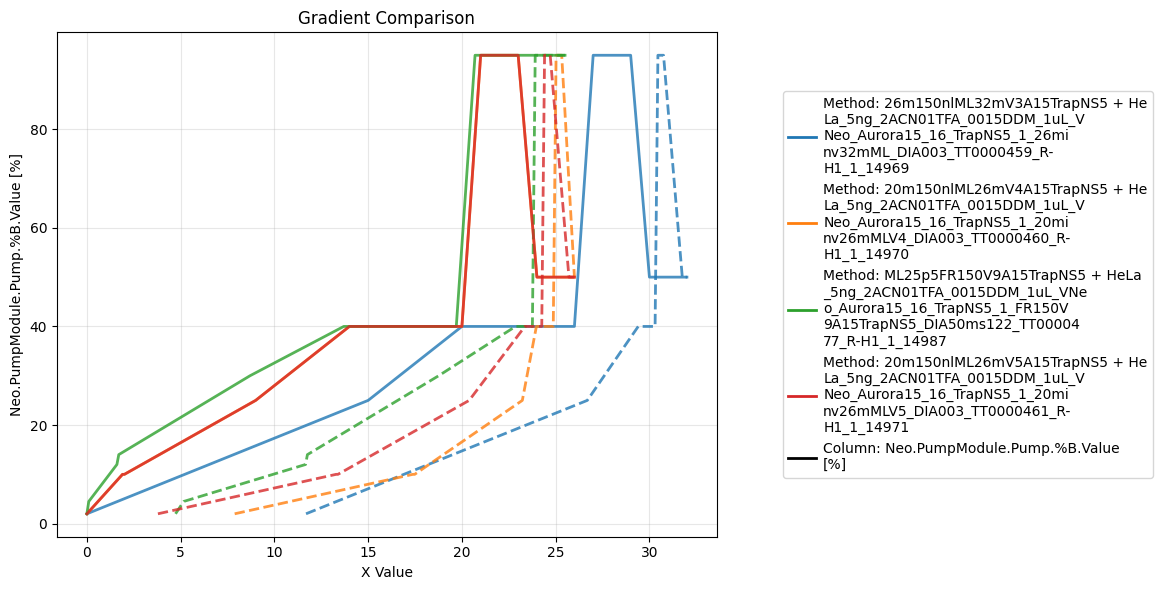

In [61]:
lccollection.plot_gradients(sample_var = sample_subset,
                            x_cols = ['time [min]', 'Actual Time to Elute Nominal %B (min)'],
                            y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'])

## FWHM Distribution

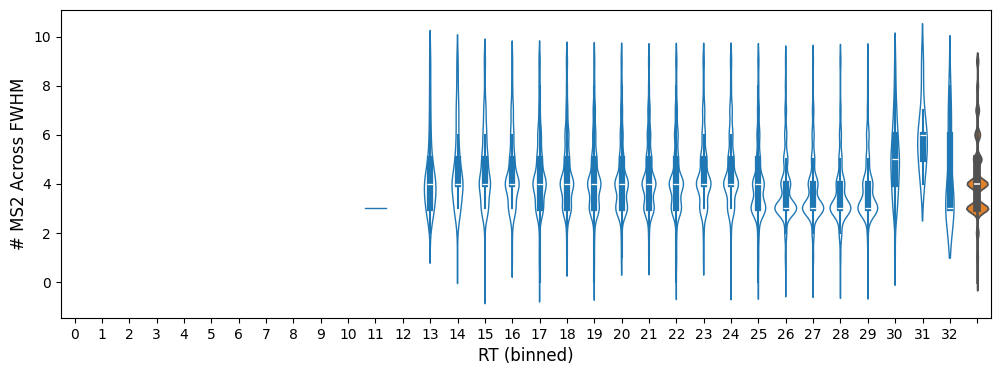

In [165]:
fwhmdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=1) 

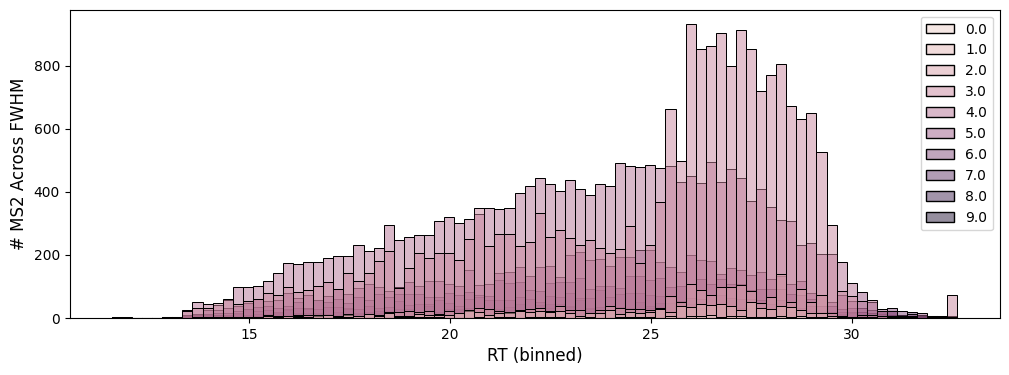

In [167]:
fwhmdist(bpscollection,
           'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_TrapNS5_1_26min_DIA003_TT0000457_R-H1_1_14967', 
           figsize=(12, 4), 
           binwidth=0.25,
           plot_type='hist')

### Plotting/Analysis

#### Checkign distribution of Values

In [29]:
def check_dist(ad, layer, samples=None, figsize=(10,6)):
    fig, ax = plt.subplots(figsize=figsize)
    df = ad.to_df(layer)
    if samples:
        df = df.loc[:, samples]

    df = df.melt(value_name=layer)

    for s in df.columns:
        sns.violinplot(data = df, x = 'File.Name', y = layer, ax=ax)
    
    plt.xticks(rotation=90)

## Compute CV

In [12]:
test = bpscollection['precursor'][:, bpscollection['precursor'].var['ms meth'].isin(['DIA003', 'DIA011RT75expandedrangeW83'])]

In [13]:
test2 = test[:, test.var['hystar_index'].astype(int) > 14701]

In [14]:
test2.var['File.Name'] = test2.var.index

/tmp/ipykernel_3371188/3159618787.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  test2.var['File.Name'] = test2.var.index


In [19]:
test2.var['input'] = test2.var['File.Name'].str.extract(r'HeLa_(\d+[np]g)_')

In [20]:
test2.layers['RTDiff'] = test2.layers['RT.Stop'] - test2.layers['RT.Start']

In [34]:
sample = 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA75msW83_TT0000314_B-B2_1_14717'

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT